# Dự đoán giá vàng bằng Vanilla RNN thuần (NumPy)

Trong notebook này, chúng ta sẽ xây dựng một mạng Vanilla Recurrent Neural Network (RNN) từ đầu (from scratch) chỉ sử dụng thư viện `numpy`. 
Mục tiêu là dự đoán giá vàng dựa trên dữ liệu lịch sử.

Notebook được chia thành các phần tách biệt, giải thích chi tiết cả toán học và mã nguồn để phục vụ cho việc tạo Slide báo cáo sau này:
1. **Tiền xử lý và làm sạch dữ liệu (Data Cleaning)**
2. **Kiến trúc mạng Vanilla RNN**
3. **Lan truyền xuôi (Forward Pass)**
4. **Lan truyền ngược qua thời gian (Backpropagation Through Time - BPTT)**
5. **Huấn luyện mô hình (Training)**
6. **Dự đoán và trực quan hóa (Prediction & Visualization)**


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# Đặt random seed để kết quả có thể tái tạo (reproducible)
np.random.seed(42)


## 1. Tiền xử lý và Làm sạch dữ liệu (Data Cleaning & Preparation)

Dữ liệu thực tế thường có nhiều nhiễu, thiếu sót và định dạng không nhất quán. Trước khi đưa vào mô hình, ta cần làm các bước sau:
- **Đọc dữ liệu**: Tải file csv chứa dữ liệu giá vàng.
- **Xử lý giá trị rỗng (Missing Values)**: Loại bỏ (drop) hoặc điền (fill) các ngày bị thiếu dữ liệu.
- **Sắp xếp theo thời gian**: Đảm bảo chuỗi thời gian liên tục từ quá khứ đến hiện tại.
- **Chuẩn hóa (Normalization)**: Đưa giá trị giá vàng về khoảng `[0, 1]` bằng Min-Max Scaling để mô hình hội tụ nhanh hơn (do các hàm kích hoạt như Tanh hoạt động tốt trong khoảng này).


In [22]:
# 1. Đọc dữ liệu
df = pd.read_csv('../data/gold_price.csv')

# 2. Làm sạch dữ liệu (Data Cleaning)
# - Chuyển cột 'date' sang định dạng datetime
df['date'] = pd.to_datetime(df['date'])

# - Sắp xếp dữ liệu theo thứ tự thời gian (rất quan trọng trong Time Series)
df = df.sort_values('date')

# - Xóa các hàng có giá trị rỗng (nếu có)
df = df.dropna()

# - Lấy giá trị giá vàng (cột 'price')
prices = df['price'].values.astype(float)

# 3. Chuẩn hóa dữ liệu (Min-Max Scaling)
# Công thức: X_scaled = (X - X_min) / (X_max - X_min)
split_raw = int(0.8 * len(prices))
train_prices_raw = prices[:split_raw]

price_min = np.min(train_prices_raw)
price_max = np.max(train_prices_raw)

# Chuẩn hóa
scaled_prices = (prices - price_min) / (price_max - price_min)

print(f"Tổng số điểm dữ liệu: {len(scaled_prices)}")
print(f"Giá trị sau chuẩn hóa (5 ngày đầu): {scaled_prices[:5]}")


Tổng số điểm dữ liệu: 13383
Giá trị sau chuẩn hóa (5 ngày đầu): [0.00031804 0.00033435 0.00031804 0.00031804 0.00031804]


### Tạo chuỗi thời gian (Sequence Generation)

Mô hình RNN cần đầu vào là một *chuỗi* dữ liệu lịch sử để dự đoán bước tiếp theo.
Chúng ta sẽ chia dữ liệu thành các cửa sổ thời gian (window/sequence) có độ dài `seq_length`.

- **X (Input)**: Giá vàng của `seq_length` ngày qua.
- **y (Target)**: Giá vàng của ngày tiếp theo.


In [23]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 10
X_data, y_data = create_sequences(scaled_prices, SEQ_LENGTH)

# Định dạng shape của Input là (Số lượng mẫu, Độ dài chuỗi, Số lượng đặc trưng)
X_data = X_data.reshape(-1, SEQ_LENGTH, 1)
y_data = y_data.reshape(-1, 1)

# Chia tập Train / Test (80% Train, 20% Test)
split = int(0.8 * len(X_data))
X_train, y_train = X_data[:split], y_data[:split]
X_test, y_test = X_data[split:], y_data[split:]

print("X_train shape:", X_train.shape) # (N, SEQ_LENGTH, 1)
print("y_train shape:", y_train.shape) # (N, 1)


X_train shape: (10698, 10, 1)
y_train shape: (10698, 1)


## 2. Kiến trúc mạng Vanilla RNN

Một cell RNN tiêu chuẩn (Vanilla RNN) duy trì một **trạng thái ẩn (hidden state)** $h_t$ qua từng bước thời gian $t$.
Trạng thái này đóng vai trò như "trí nhớ" của mạng, kết hợp thông tin từ quá khứ ($h_{t-1}$) và hiện tại ($x_t$).

Các tham số cần huấn luyện (Trọng số - Weights và Độ lệch - Biases):
- $U$: Trọng số chuyển đổi Input ($x_t$) vào Hidden state.
- $W$: Trọng số chuyển đổi Hidden state cũ ($h_{t-1}$) sang Hidden state mới ($h_t$).
- $V$: Trọng số chuyển đổi Hidden state ($h_t$) thành Output ($y_t$).
- $b_h$: Độ lệch (Bias) cho Hidden state.
- $b_y$: Độ lệch (Bias) cho Output.


In [24]:
class VanillaRNN:
    def __init__(self, input_size, hidden_size, output_size):
        self.input_dim = input_size
        self.hidden_dim = hidden_size
        self.hidden_size = hidden_size
        self.output_dim = output_size
        
        # W: input -> hidden (hidden_size, input_size) -> (32, 1)
        self.W = np.random.randn(hidden_size, input_size) * np.sqrt(2.0 / (input_size + hidden_size))
        # U: hidden -> hidden (hidden_size, hidden_size) -> (32, 32)
        self.U = np.random.randn(hidden_size, hidden_size) * np.sqrt(1.0 / hidden_size)
        # V: hidden -> output (output_size, hidden_size) -> (1, 32)
        self.V = np.random.randn(output_size, hidden_size) * np.sqrt(2.0 / (hidden_size + output_size))
        
        # Biases khởi tạo bằng 0
        self.b_h = np.zeros((hidden_size, 1))
        self.b_y = np.zeros((output_size, 1))

## 3. Lan truyền xuôi (Forward Pass)

Quá trình truyền một chuỗi đầu vào qua mạng RNN. Ở mỗi bước thời gian $t$:

1. **Cập nhật trạng thái ẩn (Hidden State)**:
   $$h_t = 	anh(U x_t + W h_{t-1} + b_h)$$
   *Hàm kích hoạt $	anh$ giúp nén các giá trị vào khoảng $[-1, 1]$.*

2. **Tính toán đầu ra dự đoán (Output)**:
   $$\hat{y}_t = V h_t + b_y$$
   *(Trong bài toán dự đoán chuỗi này, ta chỉ lấy $\hat{y}$ ở bước thời gian cuối cùng của chuỗi)*.
   
3. **Lưu trữ lại lịch sử (Caches)**:
   Ta cần lưu lại các giá trị $x_t$, $h_t$ trong suốt Forward Pass để dùng cho quá trình tính đạo hàm ở Backpropagation.


In [25]:
def forward(self, x_seq):
    # x_seq có kích thước: (seq_length, input_size)
    h_states = {}
    h_states[-1] = np.zeros((self.hidden_dim, 1))
    
    # Lặp qua từng bước thời gian
    for t in range(len(x_seq)):
        x_t = np.array(x_seq[t]).reshape(-1, 1)
        
        # Đúng chuẩn: W đi với x_t, U đi với h_{t-1}
        a_t = np.dot(self.W, x_t) + np.dot(self.U, h_states[t-1]) + self.b_h
        h_t = np.tanh(a_t)
        h_states[t] = h_t
    
    # Dự đoán đầu ra ở bước thời gian cuối cùng: y_pred = V * h_T + b_y
    y_pred = np.dot(self.V, h_states[len(x_seq)-1]) + self.b_y
    return y_pred, h_states

VanillaRNN.forward = forward

Dưới đây là phần nội dung đã được chỉnh sửa chuẩn xác về mặt toán học, định dạng LaTeX sạch sẽ (sửa các lỗi gõ dính chữ như `anh`, thiếu dấu `-`), và đồng bộ hóa hệ ký hiệu chuẩn ($W$ cho $x_t \to h_t$, $U$ cho $h_{t-1} \to h_t$, $V$ cho $h_t \to \hat{y}_t$) để đưa vào Markdown của Jupyter Notebook:

---

## 4. Lan truyền ngược qua thời gian (BPTT - Backpropagation Through Time)

Để cập nhật các trọng số trong mạng RNN, ta cần tính đạo hàm của hàm mất mát (Loss) đối với từng ma trận trọng số $(W, U, V)$ và bias $(b_h, b_y)$ bằng quy tắc chuỗi (Chain Rule) lan truyền ngược qua từng bước thời gian.

### 4.1. Hàm mất mát và Gradient tại lớp Output

Xét bài toán dự báo một bước thời gian cuối cùng (Many-to-One), hàm mất mát **Mean Squared Error (MSE)** cho một mẫu:

$$L = \frac{1}{2} (\hat{y} - y_{true})^2$$

Đạo hàm của hàm mất mát theo dự báo $\hat{y}$:

$$d\hat{y} = \frac{\partial L}{\partial \hat{y}} = \hat{y} - y_{true}$$

Vì $\hat{y} = V h_T + b_y$ (với $T$ là time-step cuối cùng $t_{cuối}$), gradient của tầng Output được tính như sau:

$$dV = \frac{\partial L}{\partial V} = d\hat{y} \cdot h_T^T$$

$$db_y = \frac{\partial L}{\partial b_y} = d\hat{y}$$

Gradient truyền từ đầu ra vào hidden state ở bước cuối cùng $T$:

$$dh_T = \frac{\partial L}{\partial h_T} = V^T \cdot d\hat{y}$$

---

### 4.2. Lan truyền ngược qua các Time-Step (từ $t = T$ về $t = 1$)

Vì các ma trận trọng số $W, U$ và bias $b_h$ được chia sẻ (shared weights) qua mọi bước thời gian, tổng gradient sẽ bằng tổng gradient tích lũy tại từng time-step $t$.

Nhắc lại công thức bước Forward:

$$a_t = W x_t + U h_{t-1} + b_h$$

$$h_t = \tanh(a_t)$$

Đạo hàm của hàm kích hoạt $\tanh(z)$ là $\tanh'(z) = 1 - \tanh^2(z) = 1 - h_t^2$.

Tại mỗi bước thời gian $t$ (duyệt ngược từ $t = T$ về $t = 1$):

1. **Gradient trước hàm kích hoạt (tại $a_t$):**

$$dh_t^{raw} = dh_t \odot (1 - h_t^2)$$

*(trong đó $\odot$ là phép nhân từng phần tử - element-wise product)*

2. **Tích lũy Gradient cho các trọng số chia sẻ:**

$$dW += dh_t^{raw} \cdot x_t^T$$

$$dU += dh_t^{raw} \cdot h_{t-1}^T$$

$$db_h += dh_t^{raw}$$

3. **Lan truyền gradient ngược về hidden state bước trước đó ($h_{t-1}$):**

$$dh_{t-1} = U^T \cdot dh_t^{raw}$$

---

> **Lưu ý về Triệt tiêu đạo hàm (Vanishing Gradient):**
> Khi mở rộng chuỗi qua nhiều bước thời gian:

$$dh_{t-k} = \left( \prod_{j=0}^{k-1} U^T \cdot \text{diag}(1 - h_{t-j}^2) \right) dh_t^{raw}$$

> Do $\vert{}1 - h_j^2\vert{} \le 1$ và phép nhân lặp liên tiếp qua ma trận $U^T$, gradient $dh_{t-k}$ có xu hướng tiến dần về $0$ theo hàm số mũ khi khoảng cách thời gian $k$ tăng lên. Đây chính là nguyên nhân Vanilla RNN gặp khó khăn khi học các phụ thuộc dài hạn (long-term dependencies).

In [26]:
import numpy as np

def backward(self, x_seq, y_true, y_pred, h_states):
    """
    x_seq: chuỗi đầu vào độ dài T (shape: [T, input_dim] hoặc list các vector)
    y_true: giá trị thực tế (scalar hoặc shape: [output_dim, 1])
    y_pred: giá trị dự báo từ forward (shape: [output_dim, 1])
    h_states: dict hoặc list chứa hidden states tại mỗi bước t. 
              Quy ước: h_states[t] là h_t sau tanh.
    """
    # Khởi tạo các mảng tích lũy gradient
    dW = np.zeros_like(self.W)      # W: input -> hidden (x_t -> h_t)
    dU = np.zeros_like(self.U)      # U: hidden -> hidden (h_{t-1} -> h_t)
    dV = np.zeros_like(self.V)      # V: hidden -> output (h_T -> y)
    db_h = np.zeros_like(self.b_h)
    db_y = np.zeros_like(self.b_y)
    
    # Đảm bảo y_pred và y_true đều là vector cột (output_dim, 1)
    y_pred = np.array(y_pred).reshape(-1, 1)
    y_true = np.array(y_true).reshape(-1, 1)
    
    # 1. Gradient tại lớp Output: dL/dy_pred = y_pred - y_true
    dy = y_pred - y_true
    
    T = len(x_seq)
    h_T = h_states[T - 1].reshape(-1, 1)
    
    # Gradient cho V và b_y
    dV = np.dot(dy, h_T.T)
    db_y = dy.reshape(self.b_y.shape)
    
    # Gradient ban đầu truyền ngược vào hidden state cuối cùng (h_T)
    dh_next = np.dot(self.V.T, dy)
    
    # 2. Vòng lặp Backpropagation Through Time (BPTT) từ T-1 về 0
    for t in reversed(range(T)):
        h_t = h_states[t].reshape(-1, 1)
        
        # Đạo hàm qua hàm tanh: dh_raw = dh_t * (1 - h_t^2)
        dh_raw = (1.0 - h_t**2) * dh_next
        
        # Vector đầu vào x_t tại thời điểm t
        x_t = np.array(x_seq[t]).reshape(-1, 1)
        
        # Lấy hidden state ở bước trước đó: h_{t-1}
        # Nếu t == 0, h_{t-1} là vector 0 (khởi tạo ban đầu)
        if t > 0:
            h_prev = h_states[t - 1].reshape(-1, 1)
        else:
            h_prev = np.zeros((self.hidden_dim, 1))
            
        # Tích lũy Gradient theo đúng ký hiệu:
        # W đi với x_t, U đi với h_{t-1}
        dW += np.dot(dh_raw, x_t.T)
        dU += np.dot(dh_raw, h_prev.T)
        db_h += dh_raw.reshape(self.b_h.shape)
        
        # Lan truyền gradient ngược tiếp về bước t-1:
        # dh_{t-1} = U^T * dh_raw (nhân với ma trận ẩn U)
        dh_next = np.dot(self.U.T, dh_raw)
        
    # 3. Cắt xén gradient (Gradient Clipping) chống bùng nổ đạo hàm
    for dparam in [dW, dU, dV, db_h, db_y]:
        np.clip(dparam, -5.0, 5.0, out=dparam)
        
    return dW, dU, dV, db_h, db_y

# Gắn hàm backward vào class
VanillaRNN.backward = backward

### Cập nhật Trọng số (Optimizer)
Chúng ta sẽ sử dụng thuật toán tối ưu cơ bản là SGD (Stochastic Gradient Descent).

Công thức cập nhật:
$W = W - 	ext{learning\_rate} 	imes dW$


In [27]:
def update_weights(self, dW, dU, dV, db_h, db_y, lr=0.005):
    self.W -= lr * dW
    self.U -= lr * dU
    self.V -= lr * dV
    self.b_h -= lr * db_h
    self.b_y -= lr * db_y

VanillaRNN.update_weights = update_weights

## 5. Huấn luyện mô hình (Training Loop)

Quá trình Training bao gồm:
1. Duyệt qua từng epoch.
2. Tại mỗi epoch, duyệt qua từng chuỗi (sequence) trong tập Train.
3. Thực hiện **Forward Pass** lấy dự đoán.
4. Tính **Loss**.
5. Thực hiện **BPTT (Backward Pass)** để tính Gradients.
6. **Cập nhật Trọng số (Update Weights)** bằng SGD.


Bắt đầu huấn luyện mô hình VanillaRNN trên 10698 mẫu...
--------------------------------------------------
Epoch [01/10] | Loss: 0.000053 | Thời gian: 1.11s
Epoch [02/10] | Loss: 0.000096 | Thời gian: 1.09s
Epoch [03/10] | Loss: 0.000030 | Thời gian: 1.04s
Epoch [04/10] | Loss: 0.000029 | Thời gian: 1.05s
Epoch [05/10] | Loss: 0.000028 | Thời gian: 1.17s
Epoch [06/10] | Loss: 0.000028 | Thời gian: 1.05s
Epoch [07/10] | Loss: 0.000028 | Thời gian: 1.04s
Epoch [08/10] | Loss: 0.000028 | Thời gian: 1.08s
Epoch [09/10] | Loss: 0.000028 | Thời gian: 1.05s
Epoch [10/10] | Loss: 0.000028 | Thời gian: 1.05s
--------------------------------------------------
Huấn luyện hoàn tất!


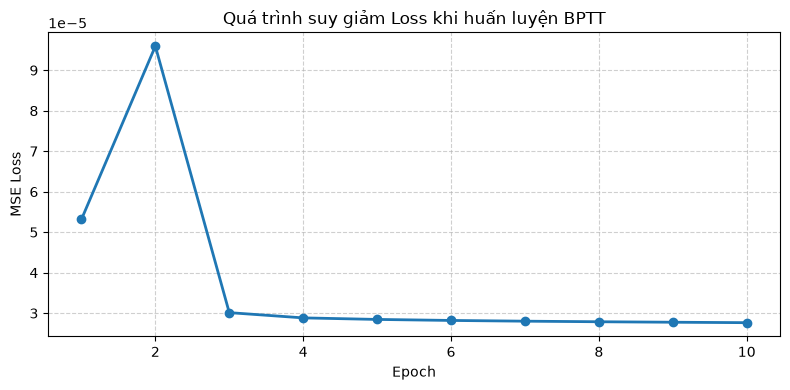

In [28]:
import time

# 1. Khởi tạo siêu tham số và mô hình
input_size = 1    # Kích thước đặc trưng tại mỗi time-step x_t
hidden_size = 32  # Số nơ-ron trạng thái ẩn h_t
output_size = 1   # Kích thước đầu ra dự báo

model = VanillaRNN(input_size, hidden_size, output_size)

epochs = 10
learning_rate = 0.005  # Với Vanilla RNN thuần, lr từ 0.001 - 0.005 thường ổn định hơn 0.01
losses = []

num_samples = len(X_train)
print(f"Bắt đầu huấn luyện mô hình VanillaRNN trên {num_samples} mẫu...")
print("-" * 50)

for epoch in range(1, epochs + 1):
    start_time = time.time()
    epoch_loss = 0.0
    
    # Huấn luyện từng mẫu (Online / Stochastic Gradient Descent)
    for i in range(num_samples):
        x_seq = X_train[i]
        
        # Đảm bảo y_true là scalar hoặc vector cột (1, 1) an toàn
        y_true = np.array(y_train[i]).reshape(-1, 1)
        
        # Bước 1: Forward pass
        y_pred, h_states = model.forward(x_seq)
        
        # Bước 2: Tính MSE Loss: 0.5 * (y_pred - y_true)^2
        diff = float(y_pred[0, 0] - y_true[0, 0])
        loss = 0.5 * (diff ** 2)
        epoch_loss += loss
        
        # Bước 3: Backward pass (BPTT - Backpropagation Through Time)
        grads = model.backward(x_seq, y_true, y_pred, h_states)
        
        # Bước 4: Cập nhật trọng số theo gradient descent
        # grads: (dW, dU, dV, db_h, db_y)
        model.update_weights(*grads, lr=learning_rate)
        
    avg_loss = epoch_loss / num_samples
    losses.append(avg_loss)
    elapsed = time.time() - start_time
    
    print(f"Epoch [{epoch:02d}/{epochs:02d}] | Loss: {avg_loss:.6f} | Thời gian: {elapsed:.2f}s")
    
    # Kiểm tra an toàn: ngắt nếu loss phân kỳ hoặc nổ gradient thành NaN
    if np.isnan(avg_loss) or np.isinf(avg_loss):
        print(f"\n[CẢNH BÁO] Huấn luyện bị dừng sớm tại epoch {epoch} do Loss bị NaN/Inf!")
        break

print("-" * 50)
print("Huấn luyện hoàn tất!")

# Vẽ biểu đồ suy giảm hàm mất mát qua các Epochs
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(losses) + 1), losses, marker='o', color='#1f77b4', linewidth=2)
plt.title("Quá trình suy giảm Loss khi huấn luyện BPTT")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 6. Dự đoán và trực quan hóa (Prediction & Visualization)

Sau khi huấn luyện xong, chúng ta dùng tập `Test` để dự đoán và vẽ biểu đồ so sánh giữa Giá trị Dự đoán và Giá trị Thực tế.


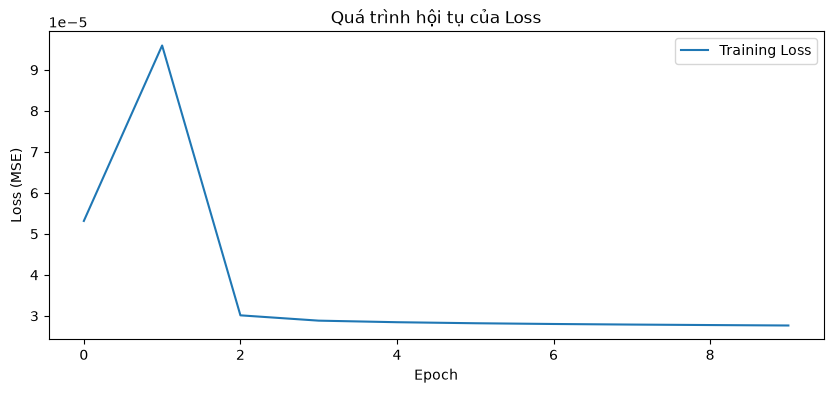

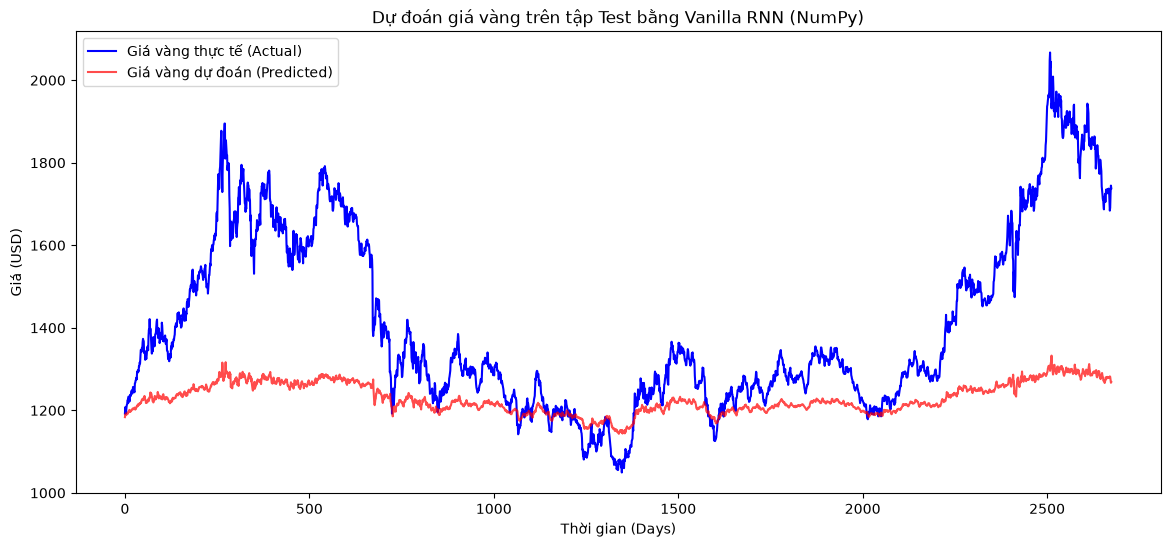

In [29]:
# Thực hiện dự đoán trên tập Test
predictions = []
for i in range(len(X_test)):
    x_seq = X_test[i]
    y_pred, _ = model.forward(x_seq)
    predictions.append(y_pred[0, 0])

predictions = np.array(predictions)

# Khôi phục dữ liệu về giá trị thực ban đầu (Inverse Min-Max Scaling)
true_values_test = y_test * (price_max - price_min) + price_min
predictions_real = predictions * (price_max - price_min) + price_min

# Vẽ biểu đồ Loss
plt.figure(figsize=(10, 4))
plt.plot(losses, label='Training Loss')
plt.title('Quá trình hội tụ của Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# Vẽ biểu đồ Dự đoán vs Thực tế
plt.figure(figsize=(14, 6))
plt.plot(true_values_test, color='blue', label='Giá vàng thực tế (Actual)')
plt.plot(predictions_real, color='red', alpha=0.7, label='Giá vàng dự đoán (Predicted)')
plt.title('Dự đoán giá vàng trên tập Test bằng Vanilla RNN (NumPy)')
plt.xlabel('Thời gian (Days)')
plt.ylabel('Giá (USD)')
plt.legend()
plt.show()
